In [1]:
!pip install transformers torch datasets

In [2]:
import pandas as pd
import tensorflow as tf
import torch
import numpy as np
import time
import datetime
import random
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from google.colab import drive

!pip install transformers
import transformers
from transformers import BertTokenizer
from torch.utils.data import TensorDataset, random_split
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler
from transformers import BertForSequenceClassification, BertConfig
from transformers import get_linear_schedule_with_warmup

from torch.optim import AdamW

from sklearn.metrics import f1_score, recall_score, precision_score, classification_report
from sklearn.preprocessing import LabelEncoder


In [4]:
df = pd.read_csv(
    "sms-classification-dataset.csv",
    encoding="windows-1252",
    sep=";",
    engine="python"
)

def fix_turkish(text):
    if isinstance(text, str):
        try:
            return text.encode("windows-1252").decode("iso-8859-9")
        except:
            return text
    return text

df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
df["text"] = df["text"].apply(fix_turkish)
df["groupText"] = df["groupText"].apply(fix_turkish)

df.head(20)


,text,group,groupText
0,Hesabınızda olağan dışı borçlandırma bulundu. ...,0,Dolandiricilik
1,Vergi borcunuz bulunmaktadır. Haciz uygulanmam...,0,Dolandiricilik
2,Hesabınızdan 8000 TLye Profesyonel Sakal Tar...,0,Dolandiricilik
3,Hesabınızda olağan dışı para aktarımına rastla...,0,Dolandiricilik
4,Ama ben ütü yapıp valiz hazırlayacağım,2,Normal
5,Paket teslim edilemedi. Yeni teslim tarihi seç...,0,Dolandiricilik
6,Yatırım platformu %300 garanti ile açıldı. Üye...,0,Dolandiricilik
7,Cok yakismissiniz bize bi tanede yanyana saril...,2,Normal
8,SY. UYEMIZ ZUMBA UCRETSIZ TANITIM DERSI C.TESI...,1,Promosyon
9,Kayıp paket: Kargonuz adres bilgisi eksik.doğr...,0,Dolandiricilik


In [5]:
!pip install ftfy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00


In [6]:
import ftfy

df["text"] = df["text"].astype(str).apply(ftfy.fix_text)
df["groupText"] = df["groupText"].astype(str).apply(ftfy.fix_text)

In [7]:
import re

def mask_percent(text):
    return re.sub(r'%\s*\d+[\w\'\-]*', '[PERCENT]', text)


In [8]:
def mask_price(text):
    return re.sub(r'\b\d{1,6}(?:[.,]\d{1,2})?\s*[-]?\s*(?:TL|tl|₺)(?:[\w\'\-]*)', '[PRICE]', text)


In [10]:
df["masked_text"] = df["text"].apply(lambda x: mask_price(mask_percent(x)))


In [12]:
df[df["text"].str.contains("%")][["text", "masked_text"]].head()


,text,masked_text
6,Yatırım platformu %300 garanti ile açıldı. Üye...,Yatırım platformu [PERCENT] garanti ile açıldı...
14,Paraf'tan Size Ozel 50 TL ye varan indirim fir...,Paraf'tan Size Ozel [PRICE] ye varan indirim f...
32,Beklenen sezon indirimi ilk once ve sadece mav...,Beklenen sezon indirimi ilk once ve sadece mav...
42,"Hyundai'den fantastik %0 faiz avantaji! ix35, ...",Hyundai'den fantastik [PERCENT] faiz avantaji!...
65,Calvin Klein IN2U Kadin/Erkek 150 ml parfumler...,Calvin Klein IN2U Kadin/Erkek 150 ml parfumler...


In [13]:
tokenizer = BertTokenizer.from_pretrained('dbmdz/bert-base-turkish-128k-uncased', do_lower_case=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/386 [00:00<?, ?B/s]

In [14]:
sentences = df.masked_text.values

In [15]:
max_len = 200

In [16]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["group"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["group"]
)
test=test_df

In [17]:
def encode_texts(text_list, tokenizer, max_len):
    input_ids = []
    attention_masks = []

    for text in text_list:
        encoded_dict = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        input_ids.append(encoded_dict["input_ids"])
        attention_masks.append(encoded_dict["attention_mask"])

    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)

    return input_ids, attention_masks


In [18]:
train_input_ids, train_attention_masks = encode_texts(
    train_df.masked_text.values, tokenizer, max_len
)
train_labels = torch.tensor(train_df.group.values, dtype=torch.long)

val_input_ids, val_attention_masks = encode_texts(
    val_df.masked_text.values, tokenizer, max_len
)
val_labels = torch.tensor(val_df.group.values, dtype=torch.long)

test_input_ids, test_attention_masks = encode_texts(
    test.masked_text.values, tokenizer, max_len
)
test_labels = torch.tensor(test.group.values, dtype=torch.long)


In [19]:
print(train_labels.dtype)


torch.int64


In [20]:
batch_size = 32

train_dataset = TensorDataset(train_input_ids, train_attention_masks, train_labels)
val_dataset   = TensorDataset(val_input_ids,  val_attention_masks,  val_labels)
test_dataset  = TensorDataset(test_input_ids, test_attention_masks, test_labels)

train_dataloader = DataLoader(
    train_dataset,
    sampler=RandomSampler(train_dataset),
    batch_size=batch_size
)

validation_dataloader = DataLoader(
    val_dataset,
    sampler=SequentialSampler(val_dataset),
    batch_size=batch_size
)

test_dataloader = DataLoader(
    test_dataset,
    sampler=SequentialSampler(test_dataset),
    batch_size=batch_size
)


In [21]:
number_of_categories = len(df['group'].unique())

In [22]:
model = BertForSequenceClassification.from_pretrained(
    "dbmdz/bert-base-turkish-128k-uncased",
    num_labels = number_of_categories,
    output_attentions = False,
    output_hidden_states = False,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


model.safetensors:   0%|          | 0.00/740M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-128k-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(128000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

In [23]:
epochs = 4

optimizer = AdamW(
    model.parameters(),
    lr=5e-5,
    eps=1e-8
)

total_steps = len(train_dataloader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)


In [24]:
def format_time(elapsed):
    elapsed_rounded = int(round((elapsed)))
    return str(datetime.timedelta(seconds=elapsed_rounded))

In [25]:
class EarlyStopping:
    def __init__(self, patience=2, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.should_stop = False

    def check(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            self.should_stop = True

        return self.should_stop


In [26]:
seed_val = 42

random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

training_stats = []
total_t0 = time.time()

early_stopper = EarlyStopping(patience=2)

for epoch_i in range(0, epochs):

    print('')
    print('======== Epoch {:} / {:} ========'.format(epoch_i + 1, epochs))

    t0 = time.time()
    total_train_loss = 0
    model.train()

    for step, batch in enumerate(train_dataloader):

        if step % 10 == 0 and not step == 0:
            elapsed = format_time(time.time() - t0)
            print('  Batch {:>5,}  of  {:>5,}.    Elapsed: {:}.'.format(
                step, len(train_dataloader), elapsed))

        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        model.zero_grad()

        output = model(
            b_input_ids,
            token_type_ids=None,
            attention_mask=b_input_mask,
            labels=b_labels
        )

        loss = output['loss']
        total_train_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

    avg_train_loss = total_train_loss / len(train_dataloader)
    training_time = format_time(time.time() - t0)

    print("  Average training loss: {0:.4f}".format(avg_train_loss))
    print("  Training epoch took: {:}".format(training_time))

    print("  Running Validation...")

    t0 = time.time()
    model.eval()
    total_val_loss = 0

    for batch in validation_dataloader:

        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        with torch.no_grad():
            output = model(
                b_input_ids,
                token_type_ids=None,
                attention_mask=b_input_mask,
                labels=b_labels
            )

        loss = output['loss']
        total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(validation_dataloader)
    validation_time = format_time(time.time() - t0)

    print("  Validation Loss: {0:.4f}".format(avg_val_loss))
    print("  Validation took: {:}".format(validation_time))

    training_stats.append({
        'epoch': epoch_i + 1,
        'Training Loss': avg_train_loss,
        'Validation Loss': avg_val_loss,
        'Training Time': training_time,
        'Validation Time': validation_time
    })

    if early_stopper.check(avg_val_loss):
        print("\nEARLY STOPPING tetiklendi, eğitim erken durduruldu!")
        break

print("")
print("Training completed in {:} (h:mm:ss)".format(format_time(time.time() - total_t0)))



======== Epoch 1 / 4 ========
  Batch    10  of    135.    Elapsed: 0:00:10.
  Batch    20  of    135.    Elapsed: 0:00:19.
  Batch    30  of    135.    Elapsed: 0:00:28.
  Batch    40  of    135.    Elapsed: 0:00:38.
  Batch    50  of    135.    Elapsed: 0:00:47.
  Batch    60  of    135.    Elapsed: 0:00:56.
  Batch    70  of    135.    Elapsed: 0:01:06.
  Batch    80  of    135.    Elapsed: 0:01:16.
  Batch    90  of    135.    Elapsed: 0:01:26.
  Batch   100  of    135.    Elapsed: 0:01:36.
  Batch   110  of    135.    Elapsed: 0:01:46.
  Batch   120  of    135.    Elapsed: 0:01:56.
  Batch   130  of    135.    Elapsed: 0:02:06.
  Average training loss: 0.0893
  Training epoch took: 0:02:11
  Running Validation...
  Validation Loss: 0.0101
  Validation took: 0:00:11

======== Epoch 2 / 4 ========
  Batch    10  of    135.    Elapsed: 0:00:09.
  Batch    20  of    135.    Elapsed: 0:00:19.
  Batch    30  of    135.    Elapsed: 0:00:29.
  Batch    40  of    135.    Elapsed: 0:00:39.

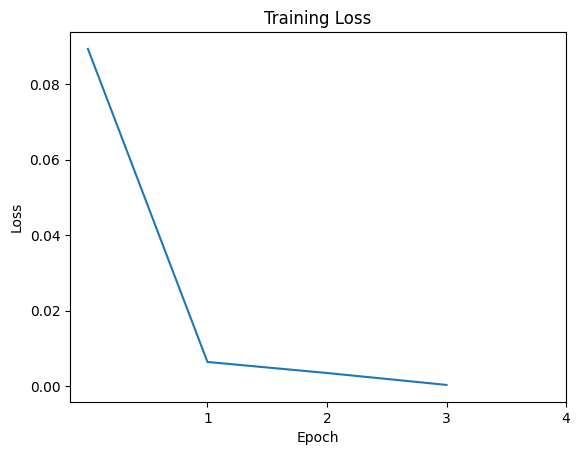

In [27]:
df_stats = pd.DataFrame(data=training_stats)
plt.plot(df_stats['Training Loss'], label="Training")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks([1, 2, 3, 4])
plt.show()

In [29]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_dataloader:
        b_input_ids = batch[0].to(device)
        b_attention_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        outputs = model(b_input_ids, attention_mask=b_attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(b_labels.cpu().numpy())


In [31]:
f_score = f1_score(all_labels, all_preds, average='macro')
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')

print("F1-Score:", f_score)
print("Precision:", precision)
print("Recall:", recall)

F1-Score: 0.9985904877209225
Precision: 0.9985018726591761
Recall: 0.9986850756081526
